In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [5]:
customer_data = pd.read_csv("Mall_Customers.csv")
customer_data = customer_data.drop(columns=["CustomerID"])
customer_data.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [11]:
customer_data = customer_data.rename(columns={"Genre": "Gender"})

In [10]:
customer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Genre                   200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 6.4 KB


In [12]:
customer_data.isna().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [13]:
customer_data["Gender"] = customer_data["Gender"].map(
    {
        "Male":0,
        "Female":1
    }
)


In [14]:
X = customer_data[['Age' , 'Annual Income (k$)' ,'Spending Score (1-100)']].values

In [15]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(random_state=42))
])

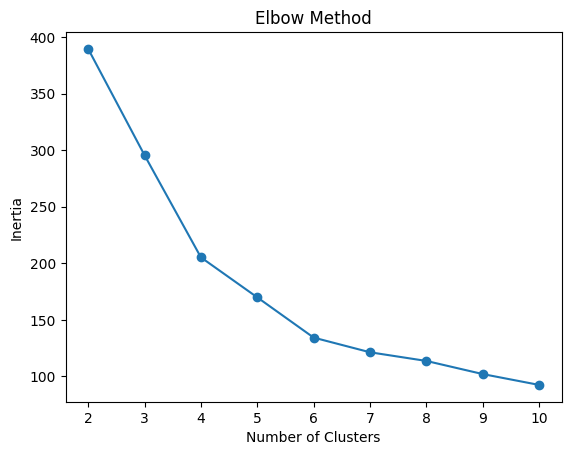

In [16]:
inertia = []
K = range(2,11)

for k in K:
    model.set_params(kmeans__n_clusters=k)
    model.fit(X)
    inertia.append(model.named_steps['kmeans'].inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method");

In [17]:
for k in range(2,11):
    model.set_params(kmeans__n_clusters=k)
    model.fit(X)
    labels = model.named_steps['kmeans'].labels_
    score = silhouette_score(
        model.named_steps['scaler'].transform(X),
        labels
    )
    
    print(f"K = {k}, Silhouette Score = {score:.4f}")
    

K = 2, Silhouette Score = 0.3355
K = 3, Silhouette Score = 0.3579
K = 4, Silhouette Score = 0.4040
K = 5, Silhouette Score = 0.4085
K = 6, Silhouette Score = 0.4311
K = 7, Silhouette Score = 0.4101
K = 8, Silhouette Score = 0.3674
K = 9, Silhouette Score = 0.3744
K = 10, Silhouette Score = 0.3619


In [18]:
model.set_params(kmeans__n_clusters=6)
model.fit(X)

centroids = model.named_steps["kmeans"].cluster_centers_
customer_data['Cluster'] = model.named_steps['kmeans'].labels_

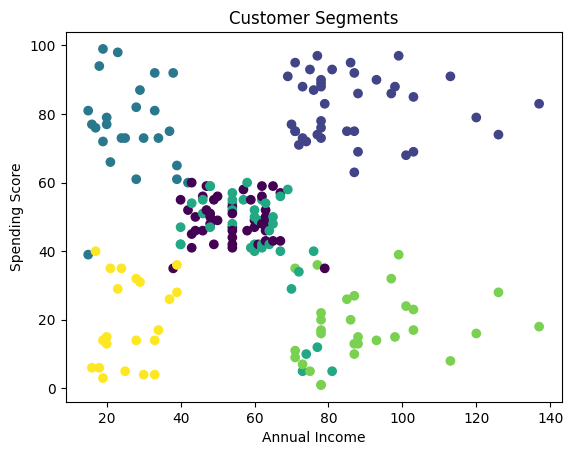

In [19]:
plt.scatter(
    customer_data['Annual Income (k$)'],
    customer_data['Spending Score (1-100)'],
    c=customer_data['Cluster']
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments");

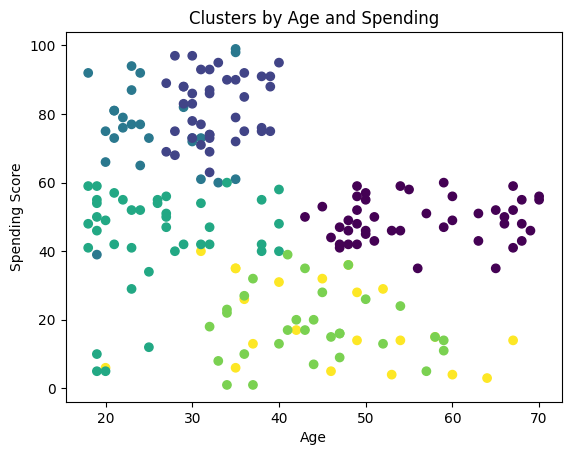

In [20]:
plt.scatter(
    customer_data['Age'],
    customer_data['Spending Score (1-100)'],
    c=customer_data['Cluster']
)

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Clusters by Age and Spending");

In [21]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init="k-means++",random_state=42)
    kmeans.fit(X)    
    wcss.append(kmeans.inertia_)

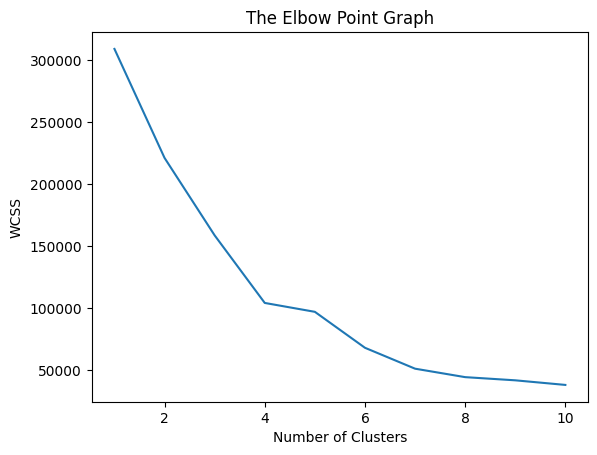

In [22]:
plt.plot(range(1,11), wcss)
plt.title("The Elbow Point Graph")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS");

In [23]:
kmeans = KMeans(n_clusters=6,init="k-means++",random_state=42)
pred = kmeans.fit_predict(X)

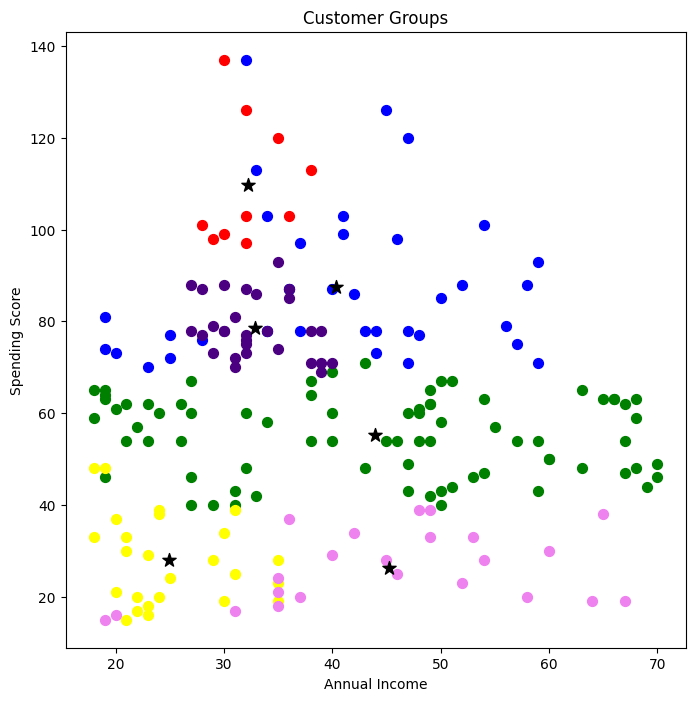

In [24]:

plt.figure(figsize=(8,8))
plt.scatter(X[pred==0,0], X[pred==0,1], s=50, c="green", label="Cluster 1")
plt.scatter(X[pred==1,0], X[pred==1,1], s=50, c="red", label="Cluster 2")
plt.scatter(X[pred==2,0], X[pred==2,1], s=50, c="yellow", label="Cluster 3")
plt.scatter(X[pred==3,0], X[pred==3,1], s=50, c="blue", label="Cluster 4")
plt.scatter(X[pred==4,0], X[pred==4,1], s=50, c="indigo", label="Cluster 5")
plt.scatter(X[pred==5,0], X[pred==5,1], s=50, c="violet", label="Cluster 6")

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100,c="black",label="Centroids", marker="*")

plt.title("Customer Groups")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score");